In [1]:
import tensorflow as tf 
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import cv2 
import os 
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop

In [2]:
# test_pathn ='D:/Python/pythonProject/code/medicalimage_classfication/DS2/DS2/test/NORMAL/IM-0005-0001.jpeg'
# new=D:/Python/sml2029/new/select/images D:/Python/sml2029/new/select/images/train/Car/Car/00008.jpeg
# data_train='D:/photoes/sam/tarin'
# data_test='D:/photoes/sam/test'
# data_validaation='D:/photoes/sam/validation'
img =image.load_img(r'D:/Python/sml2029/new/select/images/train/Car/00008.jpeg')
data_t=r"D:/Python/sml2029/new/select/images/train"
data_v = r"D:/Python/sml2029/new/select/images/valid"
data_t

FileNotFoundError: [Errno 2] No such file or directory: 'D:/Python/sml2029/new/select/images/train/Car/00008.jpeg'

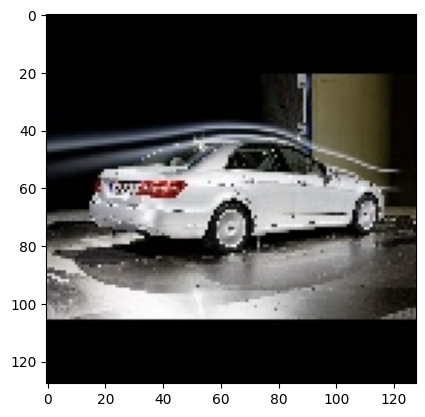

In [ ]:
plt.imshow(img)

In [ ]:
cv2.imread('D:/photoes/sam/test/happy/0.jpg').shape

(4096, 3072, 3)

In [ ]:
train= ImageDataGenerator(rescale=1/255)
validation= ImageDataGenerator(rescale=1/255)


In [ ]:
traindataset = train.flow_from_directory(data_t,target_size=(200,200),batch_size=2,class_mode='binary')
validationdataset = validation.flow_from_directory(data_v,target_size=(200,200),batch_size=2,class_mode='binary')

Found 5117 images belonging to 2 classes.
Found 5051 images belonging to 2 classes.


In [ ]:
traindataset.class_indices

In [ ]:
traindataset.classes

In [ ]:
model= tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
                                   tf.keras.layers.MaxPool2D(2,2),
                                   #
                                   tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
                                   tf.keras.layers.MaxPool2D(2,2),
                                    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
                                   tf.keras.layers.MaxPool2D(2,2),

                                   tf.keras.layers.Flatten(),

                                   tf.keras.layers.Dense(512,activation="relu"),
                                   tf.keras.layers.Dense(1,activation="sigmoid"),

                                   ])

In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(lr=0.001),
              metrics=['accuracy'])

In [ ]:
modelfit= model.fit(traindataset,steps_per_epoch=3,epochs=10,validation_data=validationdataset)

In [ ]:
# data_test = data_test+'/happy/'

In [ ]:
# for i in os.listdir(data_test):
#     print(i)
#     img=image.load_img(data_test+'//'+i,target_size=(200,200,3))
#     plt.imshow(img)
#     plt.show()

#     x=image.img_to_array(img)
#     x= np.expand_dims(x, axis=0)
#     images=np.vstack([x])
#     val=model.predict(images)
#     if val==0:
#         print("yes")
#     else:
#         print("no")

In [ ]:
# # load the model
# model = keras.models.load_model('imageClassificationModel.h5')
# # create a figure with 2 rows and 3 columns of subplots
# fig, axes = plt.subplots(2,3)
# # loop through the images in the folder
# for i, filename in enumerate(os.listdir(test_pathn)):
#   # load the image
#   img = image.load_img(os.path.join(test_pathn, filename), target_size=(224, 224))
#   # convert the image to a numpy array
# #   x = image.img_to_array(img)
# #   # expand the array to have a batch dimension
# #   x = np.expand_dims(x, axis=0)
# #   # preprocess the array using the same function as the model
# #   x = keras.applications.vgg16.preprocess_input(x)
# #   # get the prediction from the model
# #   pred = model.predict(x)
# #   # get the class index with the highest probability
# #   class_index = np.argmax(pred)
# #   # get the class name from the list of classes
# #   class_name = classes[class_index]
# #   # format the title as '<class>: <prediction>'
# #   title = f'{class_name}: {pred[0][class_index]:.2f}'
# #   # get the row and column index of the subplot
#   row = i // 3
#   col = i % 3
#   # display the image in the subplot
#   axes[row][col].imshow(img)
#   # add the title to the subplot
# #   axes[row][col].set_title(title)
# # show the figure
# plt.show()